# Data Integration: Johnson et al. 2019 × cFMD (Carlino et al. 2024)
## Research Question
**How does exposure to food-associated microbes influence the composition and stability of the human gut microbiome?**

### What this notebook does
This notebook merges all CSV files from both data sources into a unified analytical structure:

| Source | Files | Content |
|--------|-------|---------|
| **Johnson et al. 2019** (Paper 1) | `microbiome_filtered`, `micro_avg_norm`, `micro_avg_clr`, `sample_meta`, `diet_raw`, `diet_fiber`, `diet_decay`, `fiber_avg`, `nutrition_totals` | Gut microbiome + dietary data for 34 participants |
| **cFMD – Carlino et al. 2024** (Paper 2) | `combined_datasets`, `cfmd_metadata` | Food-associated microbiome from 3,393 food samples |

### Outputs produced
1. `unified_taxonomy_table.csv` — shared taxa between gut and food microbiome
2. `unified_sample_metadata.csv` — all sample metadata from both sources
3. `gut_microbiome_long.csv` — gut microbiome in long format (taxa × sample × abundance)
4. `food_microbiome_long.csv` — cFMD microbiome in long format
5. `merged_shared_taxa.csv` — abundance matrix for taxa found in BOTH datasets


---
## Section 1 – Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Ready.")


Ready.


In [2]:
#Debugging code to check paths
from pathlib import Path
import os

print("cwd:", Path.cwd())
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
print("config.py found at:", root)
print("DATA_DIR would be:", root / "data")
print("data/ exists:", (root / "data").exists())
print("microbiome_filtered.csv exists:", (root / "data" / "microbiome_filtered.csv").exists())



cwd: c:\Users\linoy\Documents\proj3\Gut-Microbiome-Project_year3
config.py found at: c:\Users\linoy\Documents\proj3\Gut-Microbiome-Project_year3
DATA_DIR would be: c:\Users\linoy\Documents\proj3\Gut-Microbiome-Project_year3\data
data/ exists: True
microbiome_filtered.csv exists: True


---
## Section 2 – Load All CSV Files

### 2.1 Johnson et al. 2019 (Gut microbiome + Diet)


In [7]:
# ── Gut microbiome matrices (taxa × samples) ───────────────────────────────────
gut_micro_filtered   = pd.read_csv(DATA_DIR / "microbiome_filtered.csv",  index_col=0)
gut_micro_avg_norm   = pd.read_csv(DATA_DIR / "micro_avg_norm.csv",       index_col=0)
gut_micro_avg_clr    = pd.read_csv(DATA_DIR / "micro_avg_clr.csv",        index_col=0)

# ── Sample + participant metadata ───────────────────────────────────────────────
gut_sample_meta      = pd.read_csv(DATA_DIR / "sample_meta.csv",          index_col=0)

# ── Dietary data ────────────────────────────────────────────────────────────────
diet_consumption_raw = pd.read_csv(DATA_DIR / "diet_raw.csv")          # food × sample matrix
diet_fiber_daily     = pd.read_csv(DATA_DIR / "diet_fiber.csv")
diet_decay_scores    = pd.read_csv(DATA_DIR / "diet_decay.csv")
fiber_participant    = pd.read_csv(DATA_DIR / "fiber_avg.csv")
nutrition_totals     = pd.read_csv(DATA_DIR / "nutrition_totals.csv")

print("Johnson et al. 2019 files loaded:")
for name, df in [
    ("gut_micro_filtered",   gut_micro_filtered),
    ("gut_micro_avg_norm",   gut_micro_avg_norm),
    ("gut_micro_avg_clr",    gut_micro_avg_clr),
    ("gut_sample_meta",      gut_sample_meta),
    ("diet_consumption_raw", diet_consumption_raw),
    ("diet_fiber_daily",     diet_fiber_daily),
    ("diet_decay_scores",    diet_decay_scores),
    ("fiber_participant",    fiber_participant),
    ("nutrition_totals",     nutrition_totals),
]:
    print(f"  {name:<25} {str(df.shape)}")


FileNotFoundError: [Errno 2] No such file or directory: '..\\..\\data\\microbiome_filtered.csv'

### 2.2 cFMD – Carlino et al. 2024 (Food microbiome)

In [ ]:
# ── Food microbiome abundance matrix (taxa × food samples) ─────────────────────
food_micro_abundance = pd.read_csv(DATA_DIR / "combined_datasets.csv", index_col=0, low_memory=False)
food_micro_abundance = food_micro_abundance.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# ── cFMD sample metadata ────────────────────────────────────────────────────────
cfmd_sample_meta     = pd.read_csv(DATA_DIR / "cfmd_metadata.csv")

print("cFMD files loaded:")
for name, df in [
    ("food_micro_abundance", food_micro_abundance),
    ("cfmd_sample_meta",     cfmd_sample_meta),
]:
    print(f"  {name:<25} {str(df.shape)}")


cFMD files loaded:
  food_micro_abundance      (5057, 3393)
  cfmd_sample_meta          (3444, 32)


---
## Section 3 – Normalise Taxonomy Labels

The two datasets use different taxonomy separators and formats:
- **Johnson (gut):** `k__Bacteria;p__Firmicutes;...;s__Faecalibacterium prausnitzii`
- **cFMD (food):** `k__Bacteria|p__Firmicutes|...|s__Lactobacillus_acidophilus|t__SGB...`

We extract a clean **genus** and **species** label from each, enabling cross-dataset matching.


In [ ]:
# ── Taxonomy parsing helpers ────────────────────────────────────────────────────

def parse_gut_taxonomy(tax_string):
    """Parse Johnson et al. semicolon-delimited taxonomy string.
    Returns dict with keys: kingdom, phylum, class, order, family, genus, species
    """
    prefixes = {"k__": "kingdom", "p__": "phylum", "c__": "class",
                "o__": "order",   "f__": "family", "g__": "genus", "s__": "species"}
    result = {v: None for v in prefixes.values()}
    for part in str(tax_string).split(";"):
        part = part.strip()
        for prefix, level in prefixes.items():
            if part.startswith(prefix):
                val = part[len(prefix):].strip()
                result[level] = val if val and val != "NA" else None
    # Clean species: strip genus name prefix if repeated
    if result["species"] and result["genus"]:
        result["species"] = result["species"].replace("_", " ").strip()
    result["clean_species"] = (result["species"] or result["genus"] or "").lower().replace(" ", "_")
    return result


def parse_food_taxonomy(tax_string):
    """Parse cFMD pipe-delimited taxonomy string.
    Drops the trailing t__SGBXXXX strain level.
    """
    prefixes = {"k__": "kingdom", "p__": "phylum", "c__": "class",
                "o__": "order",   "f__": "family", "g__": "genus", "s__": "species"}
    result = {v: None for v in prefixes.values()}
    for part in str(tax_string).split("|"):
        part = part.strip()
        if part.startswith("t__"):          # skip strain level
            continue
        for prefix, level in prefixes.items():
            if part.startswith(prefix):
                val = part[len(prefix):].strip()
                result[level] = val if val else None
    if result["species"]:
        result["species"] = result["species"].replace("_", " ").strip()
    result["clean_species"] = (result["species"] or result["genus"] or "").lower().replace(" ", "_")
    return result


# ── Build taxonomy dataframes ────────────────────────────────────────────────────
gut_taxonomy_df = pd.DataFrame(
    [parse_gut_taxonomy(t) for t in gut_micro_filtered.index],
    index=gut_micro_filtered.index
)
gut_taxonomy_df.index.name = "original_taxon"

food_taxonomy_df = pd.DataFrame(
    [parse_food_taxonomy(t) for t in food_micro_abundance.index],
    index=food_micro_abundance.index
)
food_taxonomy_df.index.name = "original_taxon"

print(f"Gut  taxonomy parsed : {len(gut_taxonomy_df)} taxa")
print(f"Food taxonomy parsed : {len(food_taxonomy_df)} taxa")
print()
print("Gut taxonomy sample:")
display(gut_taxonomy_df.head(3))
print("Food taxonomy sample:")
display(food_taxonomy_df.head(3))


Gut  taxonomy parsed : 223 taxa
Food taxonomy parsed : 5057 taxa

Gut taxonomy sample:


,kingdom,phylum,class,order,family,genus,species,clean_species
original_taxon,,,,,,,,
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;NA,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,None,bacteroides
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcaceae;g__Faecalibacterium;s__Faecalibacterium prausnitzii,Bacteria,Firmicutes,Clostridia,Clostridiales,Ruminococcaceae,Faecalibacterium,Faecalibacterium prausnitzii,faecalibacterium_prausnitzii
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides uniformis,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis,bacteroides_uniformis


Food taxonomy sample:


,kingdom,phylum,class,order,family,genus,species,clean_species
original_taxon,,,,,,,,
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis|t__SGB7985,Bacteria,Firmicutes,Bacilli,Lactobacillales,Streptococcaceae,Lactococcus,Lactococcus lactis,lactococcus_lactis
k__Bacteria|p__Actinomycetota|c__Actinomycetes|o__Propionibacteriales|f__Propionibacteriaceae|g__Cutibacterium|s__Cutibacterium_acnes|t__SGB16955,Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Cutibacterium,Cutibacterium acnes,cutibacterium_acnes
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum|t__SGB7202,Bacteria,Firmicutes,Bacilli,Lactobacillales,Lactobacillaceae,Lactiplantibacillus,Lactiplantibacillus plantarum,lactiplantibacillus_plantarum


---
## Section 4 – Unified Sample Metadata

Combine sample metadata from both sources into a single table with a `source` column.


In [ ]:
# ── Johnson gut sample metadata ─────────────────────────────────────────────────
gut_meta_unified = gut_sample_meta.reset_index().rename(columns={"index": "sample_id"})
gut_meta_unified["source"]     = "johnson_gut"
gut_meta_unified["data_type"]  = "gut_microbiome"

# Keep key columns
gut_meta_cols = ["sample_id", "source", "data_type", "UserName",
                 "StudyDayNo", "Age", "BMI", "Gender"]
gut_meta_cols = [c for c in gut_meta_cols if c in gut_meta_unified.columns]
gut_meta_unified = gut_meta_unified[gut_meta_cols].copy()

# ── cFMD food sample metadata ────────────────────────────────────────────────────
food_meta_unified = cfmd_sample_meta.rename(columns={
    "sample_id"    : "sample_id",
    "category"     : "food_category",
    "macrocategory": "food_macrocategory",
    "country"      : "country",
}).copy()
food_meta_unified["source"]    = "cfmd_food"
food_meta_unified["data_type"] = "food_microbiome"

food_meta_cols = ["sample_id", "source", "data_type",
                  "food_category", "food_macrocategory", "country"]
food_meta_cols = [c for c in food_meta_cols if c in food_meta_unified.columns]
food_meta_unified = food_meta_unified[food_meta_cols].copy()

# ── Concatenate ──────────────────────────────────────────────────────────────────
unified_sample_metadata = pd.concat([gut_meta_unified, food_meta_unified],
                                     ignore_index=True, sort=False)

print(f"Unified sample metadata: {unified_sample_metadata.shape}")
print(f"  Johnson gut samples  : {(unified_sample_metadata['source']=='johnson_gut').sum()}")
print(f"  cFMD food samples    : {(unified_sample_metadata['source']=='cfmd_food').sum()}")
display(unified_sample_metadata.head(4))

unified_sample_metadata.to_csv(DATA_DIR / "unified_sample_metadata.csv", index=False)
print("\nSaved: unified_sample_metadata.csv")


Unified sample metadata: (4010, 11)
  Johnson gut samples  : 566
  cFMD food samples    : 3444


,source,data_type,UserName,StudyDayNo,Age,BMI,Gender,sample_id,food_category,food_macrocategory,country
0,johnson_gut,gut_microbiome,MCTs01,1.0000,25.9000,25.0000,F,NaN,NaN,NaN,NaN
1,johnson_gut,gut_microbiome,MCTs01,2.0000,25.9000,25.0000,F,NaN,NaN,NaN,NaN
2,johnson_gut,gut_microbiome,MCTs01,3.0000,25.9000,25.0000,F,NaN,NaN,NaN,NaN
3,johnson_gut,gut_microbiome,MCTs01,4.0000,25.9000,25.0000,F,NaN,NaN,NaN,NaN



Saved: unified_sample_metadata.csv


---
## Section 5 – Shared Taxa: Gut × Food Microbiome

Find taxa that appear in **both** the gut microbiome (Johnson) and the food microbiome (cFMD).
Matching is done at the **species level** using the normalised `clean_species` label.


In [ ]:
# ── Species sets from each dataset ──────────────────────────────────────────────
gut_species_set  = set(gut_taxonomy_df["clean_species"].dropna())
food_species_set = set(food_taxonomy_df["clean_species"].dropna())

shared_species   = gut_species_set & food_species_set
only_gut_species = gut_species_set - food_species_set
only_food_species= food_species_set - gut_species_set

print(f"Gut  unique species  : {len(gut_species_set)}")
print(f"Food unique species  : {len(food_species_set)}")
print(f"Shared species       : {len(shared_species)}")
print(f"Gut-only species     : {len(only_gut_species)}")
print(f"Food-only species    : {len(only_food_species)}")
print()
print("Examples of shared species:")
for s in sorted(shared_species)[:15]:
    print(f"  {s}")


Gut  unique species  : 211
Food unique species  : 4770
Shared species       : 40
Gut-only species     : 171
Food-only species    : 4730

Examples of shared species:
  
  akkermansia_muciniphila
  alistipes_finegoldii
  alistipes_onderdonkii
  alistipes_putredinis
  alistipes_shahii
  anaerostipes_hadrus
  bacteroides_caccae
  bacteroides_ovatus
  bacteroides_stercoris
  bacteroides_thetaiotaomicron
  bacteroides_uniformis
  barnesiella_viscericola
  bifidobacterium_adolescentis
  bifidobacterium_bifidum


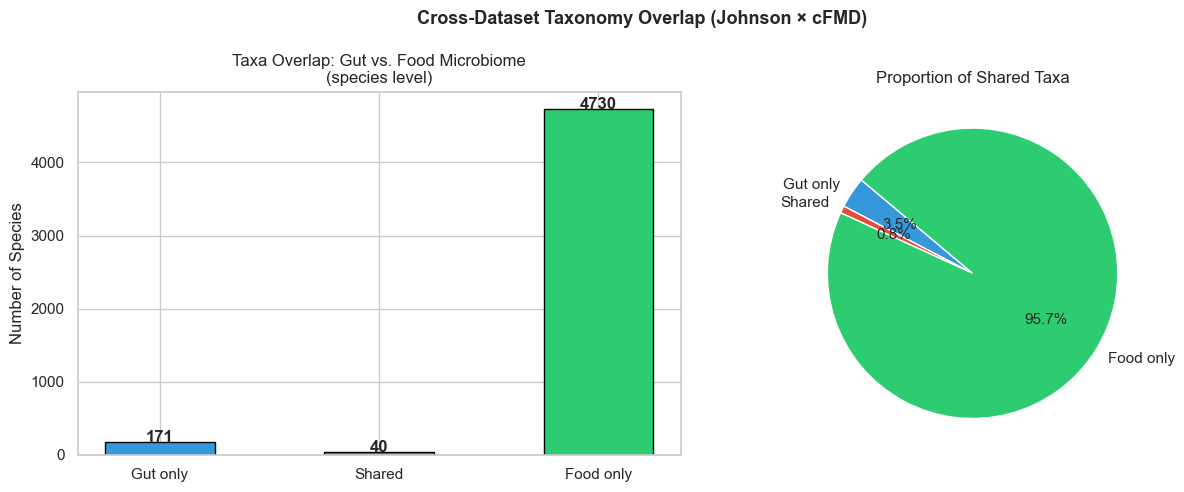

In [ ]:
# ── Venn-style bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
labels = ["Gut only", "Shared", "Food only"]
values = [len(only_gut_species), len(shared_species), len(only_food_species)]
colors = ["#3498db", "#e74c3c", "#2ecc71"]
bars = axes[0].bar(labels, values, color=colors, edgecolor="black", width=0.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha="center", fontweight="bold", fontsize=12)
axes[0].set_title("Taxa Overlap: Gut vs. Food Microbiome\n(species level)")
axes[0].set_ylabel("Number of Species")

# Pie chart
axes[1].pie(values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=140, textprops={"fontsize": 11})
axes[1].set_title("Proportion of Shared Taxa")

plt.suptitle("Cross-Dataset Taxonomy Overlap (Johnson × cFMD)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Section 6 – Unified Taxonomy Table

Build a master taxonomy reference table listing every unique taxon from both datasets,
with a flag indicating in which dataset(s) it appears.


In [ ]:
# ── Gut taxonomy with source flag ────────────────────────────────────────────────
gut_tax_flagged  = gut_taxonomy_df.copy()
gut_tax_flagged["in_gut_microbiome"]  = True
gut_tax_flagged["in_food_microbiome"] = gut_tax_flagged["clean_species"].isin(food_species_set)
gut_tax_flagged["source"] = "johnson_gut"

# ── Food taxonomy with source flag ───────────────────────────────────────────────
food_tax_flagged = food_taxonomy_df.copy()
food_tax_flagged["in_gut_microbiome"]  = food_tax_flagged["clean_species"].isin(gut_species_set)
food_tax_flagged["in_food_microbiome"] = True
food_tax_flagged["source"] = "cfmd_food"

# ── Concatenate ──────────────────────────────────────────────────────────────────
unified_taxonomy_table = pd.concat(
    [gut_tax_flagged.reset_index(), food_tax_flagged.reset_index()],
    ignore_index=True, sort=False
)

print(f"Unified taxonomy table: {unified_taxonomy_table.shape}")
display(unified_taxonomy_table.head(5))

unified_taxonomy_table.to_csv(DATA_DIR / "unified_taxonomy_table.csv", index=False)
print("\nSaved: unified_taxonomy_table.csv")


Unified taxonomy table: (5280, 12)


,original_taxon,kingdom,phylum,class,order,family,genus,species,clean_species,in_gut_microbiome,in_food_microbiome,source
0,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,None,bacteroides,True,False,johnson_gut
1,k__Bacteria;p__Firmicutes;c__Clostridia;o__Clo...,Bacteria,Firmicutes,Clostridia,Clostridiales,Ruminococcaceae,Faecalibacterium,Faecalibacterium prausnitzii,faecalibacterium_prausnitzii,True,True,johnson_gut
2,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis,bacteroides_uniformis,True,True,johnson_gut
3,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Prevotellaceae,Prevotella,Prevotella copri,prevotella_copri,True,False,johnson_gut
4,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,Alistipes putredinis,alistipes_putredinis,True,True,johnson_gut



Saved: unified_taxonomy_table.csv


---
## Section 7 – Long-Format Abundance Tables

Convert both wide matrices (taxa × samples) to long format (one row per taxon-sample pair).
This format is optimal for statistical modelling and merging.


In [ ]:
# ── Gut microbiome → long format ────────────────────────────────────────────────
gut_micro_filtered_clean = gut_micro_filtered.copy()
gut_micro_filtered_clean.index.name = "original_taxon"

# Add clean species label
gut_micro_filtered_clean["clean_species"] = gut_taxonomy_df["clean_species"]

gut_long = (
    gut_micro_filtered_clean
    .reset_index()
    .melt(id_vars=["original_taxon", "clean_species"],
          var_name="sample_id",
          value_name="relative_abundance")
)
gut_long["source"] = "johnson_gut"

# Drop zero-abundance rows to save memory
gut_long = gut_long[gut_long["relative_abundance"] > 0].reset_index(drop=True)

print(f"Gut microbiome long format : {gut_long.shape}")
display(gut_long.head(3))
gut_long.to_csv(DATA_DIR / "gut_microbiome_long.csv", index=False)
print("Saved: gut_microbiome_long.csv")


Gut microbiome long format : (98242, 5)


,original_taxon,clean_species,sample_id,relative_abundance,source
0,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,bacteroides,MCT.f.0002,79055,johnson_gut
1,k__Bacteria;p__Firmicutes;c__Clostridia;o__Clo...,faecalibacterium_prausnitzii,MCT.f.0002,2421,johnson_gut
2,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,bacteroides_uniformis,MCT.f.0002,39779,johnson_gut


Saved: gut_microbiome_long.csv


In [ ]:
# ── Food microbiome → long format ───────────────────────────────────────────────
food_micro_clean = food_micro_abundance.copy()
food_micro_clean.index.name = "original_taxon"

# Add clean species label
food_micro_clean["clean_species"] = food_taxonomy_df["clean_species"]

food_long = (
    food_micro_clean
    .reset_index()
    .melt(id_vars=["original_taxon", "clean_species"],
          var_name="full_sample_id",
          value_name="relative_abundance")
)

# Extract short sample_id (strip StudyName__ prefix)
food_long["sample_id"] = food_long["full_sample_id"].str.split("__").str[-1]
food_long = food_long.drop(columns="full_sample_id")
food_long["source"] = "cfmd_food"

# Merge food category from metadata
food_long = food_long.merge(
    cfmd_sample_meta[["sample_id", "category", "macrocategory", "country"]],
    on="sample_id", how="left"
)

# Drop zeros
food_long = food_long[food_long["relative_abundance"] > 0].reset_index(drop=True)

print(f"Food microbiome long format : {food_long.shape}")
display(food_long.head(3))
food_long.to_csv(DATA_DIR / "food_microbiome_long.csv", index=False)
print("Saved: food_microbiome_long.csv")


Food microbiome long format : (94491, 8)


,original_taxon,clean_species,relative_abundance,sample_id,source,category,macrocategory,country
0,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,lactococcus_lactis,0.1411,SRR8742576,cfmd_food,fermented_seeds,food,BRA
1,k__Bacteria|p__Pseudomonadota|c__Gammaproteoba...,pantoea_coffeiphila,0.1039,SRR8742576,cfmd_food,fermented_seeds,food,BRA
2,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,limosilactobacillus_fermentum,14.7489,SRR8742576,cfmd_food,fermented_seeds,food,BRA


Saved: food_microbiome_long.csv


---
## Section 8 – Merged Abundance Matrix for Shared Taxa

Build a merged abundance matrix containing **only taxa found in both datasets**.
- Rows = shared taxa (clean_species)
- Columns = gut samples + food samples
- Values = relative abundance

This is the core matrix for comparing food-derived vs. gut microbiome profiles.


In [ ]:
# ── Subset gut matrix to shared taxa ────────────────────────────────────────────
gut_tax_map   = gut_taxonomy_df["clean_species"].to_dict()   # original_taxon → clean_species
food_tax_map  = food_taxonomy_df["clean_species"].to_dict()

# Gut: reindex rows by clean_species
gut_for_merge = gut_micro_filtered.copy()
gut_for_merge.index = gut_for_merge.index.map(gut_tax_map)
gut_for_merge = (
    gut_for_merge[gut_for_merge.index.isin(shared_species)]
    .groupby(level=0).mean()       # average if same clean_species maps to multiple rows
)

# Food: reindex rows by clean_species
food_for_merge = food_micro_abundance.copy()
food_for_merge.index = food_for_merge.index.map(food_tax_map)
food_for_merge = (
    food_for_merge[food_for_merge.index.isin(shared_species)]
    .groupby(level=0).mean()
)

# Rename columns to avoid collision
gut_for_merge.columns  = ["gut__"  + c for c in gut_for_merge.columns]
food_for_merge.columns = ["food__" + c for c in food_for_merge.columns]

# Merge on shared taxa (inner join on index)
merged_shared_taxa = gut_for_merge.join(food_for_merge, how="inner")
merged_shared_taxa.index.name = "clean_species"

print(f"Merged shared taxa matrix: {merged_shared_taxa.shape}")
print(f"  Shared taxa (rows)     : {merged_shared_taxa.shape[0]}")
print(f"  Gut sample columns     : {gut_for_merge.shape[1]}")
print(f"  Food sample columns    : {food_for_merge.shape[1]}")
display(merged_shared_taxa.iloc[:5, :6])

merged_shared_taxa.to_csv(DATA_DIR / "merged_shared_taxa.csv")
print("\nSaved: merged_shared_taxa.csv")


Merged shared taxa matrix: (40, 3876)
  Shared taxa (rows)     : 40
  Gut sample columns     : 483
  Food sample columns    : 3393


,gut__MCT.f.0002,gut__MCT.f.0003,gut__MCT.f.0004,gut__MCT.f.0005,gut__MCT.f.0006,gut__MCT.f.0007
clean_species,,,,,,
,1272.1538,2616.3846,1291.6154,1232.9231,1317.8462,1266.3077
akkermansia_muciniphila,79.0000,63.0000,135.0000,10.0000,22.0000,35.0000
alistipes_finegoldii,3554.0000,129.0000,2160.0000,1952.0000,1467.0000,1609.0000
alistipes_onderdonkii,3723.0000,111.0000,1993.0000,2818.0000,1804.0000,2479.0000
alistipes_putredinis,18393.0000,561.0000,11742.0000,15831.0000,14319.0000,16541.0000



Saved: merged_shared_taxa.csv


---
## Section 9 – Integration Summary

### Files produced by this notebook

| File | Rows | Description |
|------|------|-------------|
| `unified_sample_metadata.csv` | 566 gut + 3,444 food | All sample metadata from both sources |
| `unified_taxonomy_table.csv` | gut + food taxa | Full taxonomy with cross-dataset flags |
| `gut_microbiome_long.csv` | non-zero entries | Gut microbiome in long format |
| `food_microbiome_long.csv` | non-zero entries | cFMD food microbiome in long format |
| `merged_shared_taxa.csv` | shared taxa | Abundance matrix for taxa found in both datasets |

### Next steps
- Use `merged_shared_taxa.csv` to compare gut vs. food abundance profiles for shared taxa
- Use `unified_sample_metadata.csv` as a lookup for participant/food metadata in all analyses
- Feed `merged_shared_taxa.csv` into the FME analysis notebook for weight derivation


In [ ]:
# ── Final summary printout ───────────────────────────────────────────────────────
outputs = {
    "unified_sample_metadata.csv" : unified_sample_metadata,
    "unified_taxonomy_table.csv"  : unified_taxonomy_table,
    "gut_microbiome_long.csv"     : gut_long,
    "food_microbiome_long.csv"    : food_long,
    "merged_shared_taxa.csv"      : merged_shared_taxa,
}

print("=" * 55)
print(f"{'File':<35} {'Shape':>12}")
print("=" * 55)
for fname, df in outputs.items():
    print(f"  {fname:<33} {str(df.shape):>12}")
print("=" * 55)
print(f"\nShared taxa between gut and food microbiome: {len(shared_species)}")
print(f"Gut-only taxa  : {len(only_gut_species)}")
print(f"Food-only taxa : {len(only_food_species)}")


File                                       Shape
  unified_sample_metadata.csv         (4010, 11)
  unified_taxonomy_table.csv          (5280, 12)
  gut_microbiome_long.csv             (98242, 5)
  food_microbiome_long.csv            (94491, 8)
  merged_shared_taxa.csv              (40, 3876)

Shared taxa between gut and food microbiome: 40
Gut-only taxa  : 171
Food-only taxa : 4730
